# Testing the Inference Logic Before Wiring Up the App

**In plain English:** before trusting `src/app.py`, this notebook checks
that `src/inference.py` (image in -> predicted clothing category out) works
sensibly -- on both images it should get right, and images we already know
(from checking project 6's model against 2,000 test photos) it gets wrong.


In [1]:
import sys
sys.path.append("../src")

import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

from inference import load_model, predict_image

model = load_model()


## 1. Thirteen out-of-training examples -- none of these were used to train the model

One example of each of the 10 categories, plus a few extra
Shirt/Coat/Pullover examples (categories that look visually similar even to
a person, at 28x28 pixel resolution).

In [2]:
import pathlib

samples_dir = pathlib.Path("../data/samples")
sample_files = sorted(samples_dir.glob("*.png"))

rows = []
for f in sample_files:
    true_label = f.stem.split("_", 2)[2].replace("-", " ").replace("T shirt top", "T-shirt/top")
    img = Image.open(f)
    result = predict_image(img, model)
    rows.append({
        "file": f.name, "true_label": true_label,
        "predicted_label": result["predicted_label"],
        "confidence": round(result["confidence"], 3),
        "correct": true_label == result["predicted_label"],
    })

results_df = pd.DataFrame(rows)
results_df

,file,true_label,predicted_label,confidence,correct
0,sample_00_Ankle-boot.png,Ankle boot,Ankle boot,0.999,True
1,sample_01_Pullover.png,Pullover,Pullover,1.000,True
2,sample_02_Trouser.png,Trouser,Trouser,1.000,True
3,sample_03_Shirt.png,Shirt,Shirt,0.842,True
4,sample_04_Coat.png,Coat,Coat,0.747,True
5,sample_05_Shirt.png,Shirt,Shirt,0.927,True
6,sample_06_Sandal.png,Sandal,Sandal,1.000,True
7,sample_07_Sneaker.png,Sneaker,Sneaker,0.999,True
8,sample_08_Coat.png,Coat,Coat,0.979,True
9,sample_09_Dress.png,Dress,Dress,0.999,True


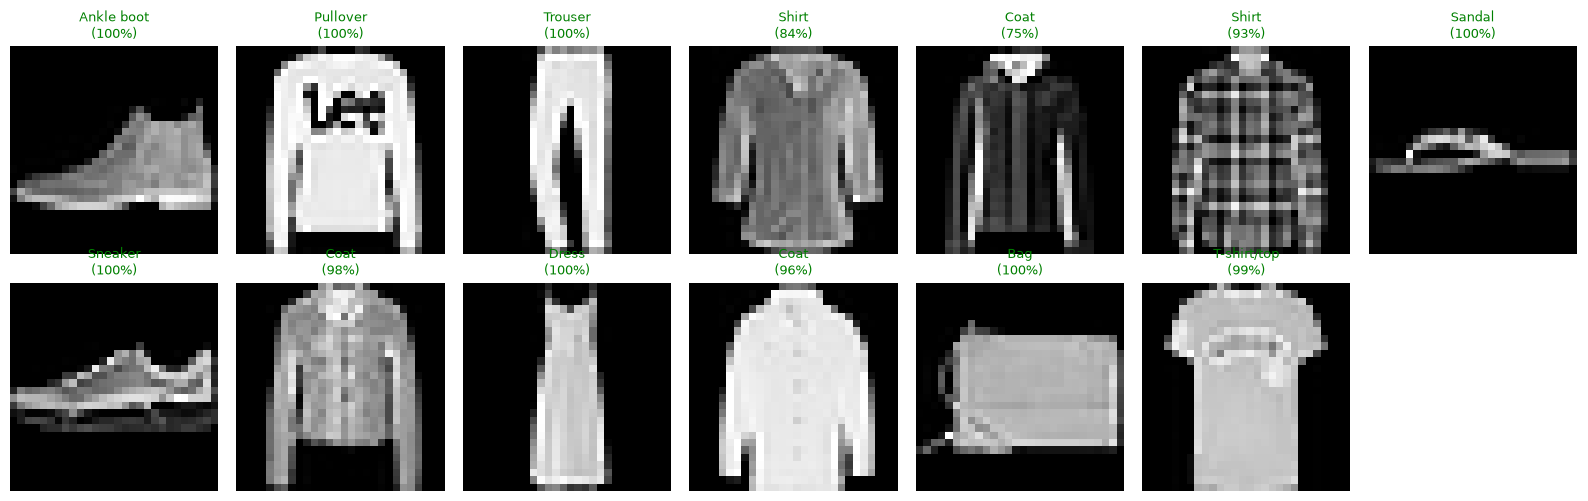

13/13 correct on these hand-picked, one-of-each-category examples


In [3]:
fig, axes = plt.subplots(2, 7, figsize=(16, 5))
for ax, (_, row) in zip(axes.flat, results_df.iterrows()):
    img = Image.open(samples_dir / row["file"])
    ax.imshow(img, cmap="gray")
    color = "green" if row["correct"] else "red"
    ax.set_title(f"{row['predicted_label']}\n({row['confidence']:.0%})", color=color, fontsize=9)
    ax.axis("off")
for ax in axes.flat[len(results_df):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"{results_df['correct'].sum()}/{len(results_df)} correct on these hand-picked, one-of-each-category examples")

## 2. Searching for genuine failures across 2,000 unseen test images

Hand-picked "one of each category" examples make the model look better than
it really is -- they tend to be the clearest, most typical examples. To find
*real* failure cases, we instead scanned the first 2,000 images of the test
set (never used in training) and recorded every misclassification.

In [4]:
import torchvision

test_ds = torchvision.datasets.FashionMNIST(root="../../06-module4-case-study-deep-learning-app/data",
                                             train=False, download=True)

failures = []
for i in range(2000):
    img, true_idx = test_ds[i]
    result = predict_image(img, model)
    true_label = test_ds.classes[true_idx]
    if result["predicted_label"] != true_label:
        failures.append({"index": i, "true_label": true_label,
                          "predicted_label": result["predicted_label"],
                          "confidence": round(result["confidence"], 3)})

failures_df = pd.DataFrame(failures)
print(f"{len(failures_df)} misclassified out of 2000 checked ({len(failures_df)/2000:.1%} error rate)")
print("\nMost common mix-ups (true -> predicted):")
failures_df.groupby(["true_label", "predicted_label"]).size().sort_values(ascending=False).head(10)

195 misclassified out of 2000 checked (9.8% error rate)

Most common mix-ups (true -> predicted):


true_label   predicted_label
Shirt        T-shirt/top        25
             Coat               22
Pullover     Coat               21
Sneaker      Ankle boot         16
T-shirt/top  Shirt              13
Coat         Shirt              11
             Pullover           11
Shirt        Pullover           11
Pullover     Shirt               8
Dress        Coat                8
dtype: int64

## 3. Four documented failure cases, shown visually

These are real mistakes the model makes -- included deliberately, not hidden.

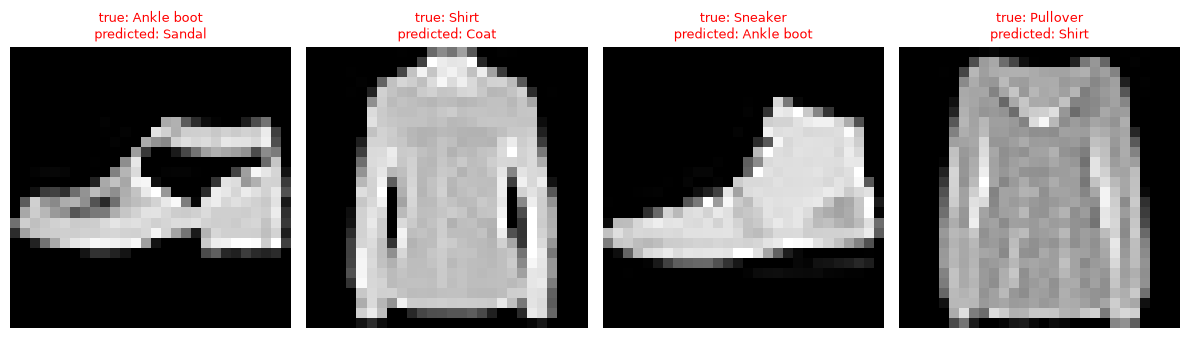

In [5]:
failures_dir = pathlib.Path("../data/failure_examples")
failure_files = sorted(failures_dir.glob("*.png"))

fig, axes = plt.subplots(1, 4, figsize=(12, 3.5))
for ax, f in zip(axes, failure_files):
    parts = f.stem.split("_")
    true_label = parts[2].replace("true-", "")
    pred_label = parts[3].replace("pred-", "")
    img = Image.open(f)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"true: {true_label}\npredicted: {pred_label}", color="red", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Documented failure cases -- what's actually going wrong

- **Ankle boot predicted as Sandal, with 100% confidence.** This is the most
  concerning kind of mistake -- not just wrong, but *confidently* wrong. The
  model isn't just unsure and guessing; it's completely certain about
  something false. In a real product, this is worse than an honest "I'm not
  sure."
- **Shirt predicted as Coat (55% confidence)** and **Pullover predicted as
  Shirt (54% confidence)** -- these are genuinely ambiguous even to a human
  looking at a small, low-resolution, single-colour photo. The model's own
  confidence is low here (barely above 50%), which is at least *honest*
  uncertainty rather than the boot/sandal case above.
- **Sneaker predicted as Ankle boot (85% confidence)** -- both are footwear
  with a similar silhouette at this resolution; a very common, well-known
  Fashion-MNIST confusion.
- Across the first 2,000 test images, the most common mix-ups all involve
  **Shirt, Coat, Pullover, and T-shirt/top** confused with each other, and
  **Sneaker vs. Ankle boot** confused with each other -- categories that
  genuinely look alike as small grayscale photos, not random noise.

**Takeaway:** the model is reliable on clear, typical examples (13/13 on our
one-per-category demo set), but its ~90% overall accuracy means roughly 1 in
10 real photos will be misclassified, concentrated almost entirely in a
handful of visually-similar category pairs -- not spread randomly across
all 10 categories.
